# Transfer Learning USAD — Submatriz Canal Único (Sensor 203) v5

**v5 changes:** Opción E (beta=0, decoder2 fuera del score), Opción C (umbral multi-candidato + métricas por ventana), Opción D (z_size=7, bottleneck monotónico).

## Cell 1 — Instalación de dependencias

In [1]:
!pip install torch torchvision plotly scikit-learn pandas numpy matplotlib requests --quiet

## Cell 2 — Imports

In [2]:
import io
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import torch
import torch.nn as nn
import torch.utils.data as data_utils
from abc import ABC, abstractmethod
from dataclasses import dataclass, field
from typing import Dict, List, Optional
from scipy.signal import butter, filtfilt
from sklearn.metrics import (
    precision_recall_curve,
    roc_curve,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix as sk_confusion_matrix,
)

print('Imports OK')

Imports OK


## Cell 3 — Clonar repositorio y configurar módulos

> **Reemplaza `REPO_URL` con la URL de tu repositorio en GitHub.**

In [3]:
import os, sys

REPO_URL = "https://github.com/ronvas234/data-science-monograph.git"  # <-- reemplazar
REPO_DIR = "data-science-monograph"

# Clonar solo si no existe
if not os.path.exists(REPO_DIR):
    os.system(f"git clone {REPO_URL}")

# Cambiar al directorio del repo (solo si aún no estamos dentro)
if os.path.basename(os.getcwd()) != REPO_DIR:
    os.chdir(REPO_DIR)

# Agregar modelos/usad al sys.path para que `from usad import ...` encuentre utils.py
USAD_MODULE_PATH = os.path.abspath("modelos/usad")
if USAD_MODULE_PATH not in sys.path:
    sys.path.insert(0, USAD_MODULE_PATH)

print(f"CWD: {os.getcwd()}")
print(f"USAD path en sys.path: {USAD_MODULE_PATH}")

# Importar clases de USAD — ahora funciona porque utils.py está en el mismo path
from usad import Encoder, Decoder, UsadModel

print("UsadModel cargado:", UsadModel)

CWD: /content/data-science-monograph
USAD path en sys.path: /content/data-science-monograph/modelos/usad
UsadModel cargado: <class 'usad.UsadModel'>


## Cell 4 — LinearDecoder (adaptación para Z-score)

El `Decoder` original de USAD termina con `Sigmoid`, diseñado para datos MinMax [0,1].  
Con normalización Z-score los valores pueden ser negativos, por lo que se reemplaza
la activación final por una capa lineal sin activación.

In [4]:
class LinearDecoder(nn.Module):
    """Decoder sin Sigmoid final — compatible con datos Z-score (rango irrestricto)."""

    def __init__(self, latent_size: int, out_size: int):
        super().__init__()
        self.linear1 = nn.Linear(latent_size, int(out_size / 4))
        self.linear2 = nn.Linear(int(out_size / 4), int(out_size / 2))
        self.linear3 = nn.Linear(int(out_size / 2), out_size)
        self.relu = nn.ReLU(True)

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        out = self.relu(self.linear1(z))
        out = self.relu(self.linear2(out))
        return self.linear3(out)  # salida lineal, sin Sigmoid


class UsadModelLinear(nn.Module):
    """UsadModel con LinearDecoder en lugar del Decoder con Sigmoid."""

    def __init__(self, w_size: int, z_size: int):
        super().__init__()
        self.encoder  = Encoder(w_size, z_size)
        self.decoder1 = LinearDecoder(z_size, w_size)
        self.decoder2 = LinearDecoder(z_size, w_size)

    def training_step(self, batch: torch.Tensor, n: int):
        z  = self.encoder(batch)
        w1 = self.decoder1(z)
        w2 = self.decoder2(z)
        w3 = self.decoder2(self.encoder(w1))
        loss1 = (1 / n) * torch.mean((batch - w1) ** 2) + (1 - 1 / n) * torch.mean((batch - w3) ** 2)
        loss2 = (1 / n) * torch.mean((batch - w2) ** 2) - (1 - 1 / n) * torch.mean((batch - w3) ** 2)
        return loss1, loss2

    def validation_step(self, batch: torch.Tensor, n: int) -> Dict:
        with torch.no_grad():
            z  = self.encoder(batch)
            w1 = self.decoder1(z)
            w2 = self.decoder2(z)
            w3 = self.decoder2(self.encoder(w1))
            loss1 = (1 / n) * torch.mean((batch - w1) ** 2) + (1 - 1 / n) * torch.mean((batch - w3) ** 2)
            loss2 = (1 / n) * torch.mean((batch - w2) ** 2) - (1 - 1 / n) * torch.mean((batch - w3) ** 2)
        return {'val_loss1': loss1, 'val_loss2': loss2}

    def validation_epoch_end(self, outputs: List[Dict]) -> Dict:
        loss1 = torch.stack([x['val_loss1'] for x in outputs]).mean()
        loss2 = torch.stack([x['val_loss2'] for x in outputs]).mean()
        return {'val_loss1': loss1.item(), 'val_loss2': loss2.item()}


print('LinearDecoder y UsadModelLinear definidos')

LinearDecoder y UsadModelLinear definidos


## Cell 5 — DataConfig

In [ ]:
@dataclass
class DataConfig:
    """Centraliza todos los hiperparámetros — sin comportamiento (S)."""

    # Rutas locales (relativas al directorio del repo clonado en Cell 3)
    csv_path:   str = "modelos/usad/data/plan_b/203.csv"
    model_path: str = "modelos/usad/model.pth"

    # Filtro temporal — idéntico al notebook de referencia (Cell 13)
    date_start: str = "2023-01-01"
    date_end:   str = "2023-06-30"

    # Ventanas — idéntico al notebook de referencia (Cell 21)
    window_size: int   = 30
    stride:      int   = 10
    sentinel:    float = -2000.0

    # Dimensiones del modelo nuevo (canal único)
    w_size: int = 30    # = window_size * 1 canal
    z_size: int = 7     # Opción D: bottleneck monotónico (30→15→7→7) — v4 tenía 15 (expansivo)

    # Dimensiones del modelo preentrenado (SWaT, 612 = 12 pasos × 51 sensores)
    w_size_orig: int = 612
    z_size_orig: int = 120

    # Entrenamiento
    epochs_phase1: int   = 50   # P1: calentamiento extendido — encoder necesita warmup real
    epochs_phase2: int   = 300  # P1: early stopping decide cuándo parar
    batch_size:    int   = 64
    lr:            float = 1e-3
    lr_decoder2:   float = 3e-4  # P5: LR diferencial — estabiliza componente adversarial de AE2
    patience:      int   = 20   # épocas sin mejora en val_loss1 antes de detener
    alpha:         float = 1.0  # Opción E: solo AE1 contribuye al score (beta=0)
    beta:          float = 0.0  # Opción E: decoder2 en modo fallo adversarial — excluir del score

    # Dispositivo
    device: str = field(
        default_factory=lambda: "cuda" if torch.cuda.is_available() else "cpu"
    )


print('DataConfig OK')


## Cell 6 — AbstractDataLoader + TimeSeriesLoader

In [6]:
class AbstractDataLoader(ABC):
    """Abstracción para carga de datos (D — depender de abstracciones)."""

    @abstractmethod
    def load(self) -> pd.DataFrame:
        """Retorna DataFrame indexado por fecha_hora con columnas [t, flag, Split, t_mask]."""
        ...


class TimeSeriesLoader(AbstractDataLoader):
    """Carga CSV desde ruta local, parsea fechas y aplica filtro temporal (S)."""

    def __init__(self, config: DataConfig):
        self._cfg = config

    def load(self) -> pd.DataFrame:
        df = self._read_csv(self._cfg.csv_path)
        df = self._parse_and_index(df)
        df = self._apply_temporal_filter(df)
        return df

    def _read_csv(self, path: str) -> pd.DataFrame:
        return pd.read_csv(path)

    def _parse_and_index(self, df: pd.DataFrame) -> pd.DataFrame:
        # Idéntico al notebook de referencia Cell 13
        df['fecha_hora'] = pd.to_datetime(df['fecha_hora'], format='%Y-%m-%d %H:%M:%S')
        return df.set_index('fecha_hora')

    def _apply_temporal_filter(self, df: pd.DataFrame) -> pd.DataFrame:
        # Idéntico al notebook de referencia Cell 13
        return df[(df.index >= self._cfg.date_start) & (df.index <= self._cfg.date_end)]


print('TimeSeriesLoader OK')

TimeSeriesLoader OK


## Cell 6b — FiltFiltPreprocessor (suavizado Butterworth antes de Z-score)

In [7]:
class FiltFiltPreprocessor:
    """Butterworth lowpass bidireccional (zero-phase) aplicado a señal cruda.

    Se ejecuta ANTES de ZScoreNormalizer para suavizar ruido de alta frecuencia
    en datos de temperatura. Preserva el valor sentinel sin filtrarlo.
    """

    def __init__(self, cutoff_hz: float = 0.05, order: int = 2, sentinel: float = -2000.0):
        self._cutoff   = cutoff_hz
        self._order    = order
        self._sentinel = sentinel

    def apply(self, series: pd.Series) -> pd.Series:
        """Filtra la serie preservando posiciones con valor sentinel.

        1. Reemplaza sentinel con NaN, interpola linealmente (evita artefactos en filtfilt)
        2. Aplica filtfilt — zero-phase, sin desfase temporal en las etiquetas
        3. Restaura posiciones sentinel al valor original
        """
        b, a = butter(self._order, self._cutoff, btype='low', analog=False)

        values = series.values.copy().astype(np.float64)
        sentinel_mask = (values == self._sentinel)

        values[sentinel_mask] = np.nan
        s_interp = pd.Series(values, index=series.index).interpolate(
            method='linear', limit_direction='both'
        )
        filtered = filtfilt(b, a, s_interp.values)
        filtered[sentinel_mask] = self._sentinel

        return pd.Series(filtered.astype(np.float32), index=series.index)


print('FiltFiltPreprocessor OK')

FiltFiltPreprocessor OK


## Cell 7 — ZScoreNormalizer

In [8]:
class ZScoreNormalizer:
    """Normalización Z-score — solo normaliza (S).

    Idéntico al notebook de referencia Cell 19:
      media = data_train[data_train.flag==0]['t'].mean()
      std   = data_train[data_train.flag==0]['t'].std()
    """

    def __init__(self, sentinel: float = -2000.0):
        self.sentinel = sentinel
        self.mean_: Optional[float] = None
        self.std_:  Optional[float] = None

    def fit(self, series: pd.Series, flag: pd.Series) -> 'ZScoreNormalizer':
        """Calcula media/std solo sobre valores normales (flag==0) del conjunto de entrenamiento."""
        valid = series[flag == 0]
        self.mean_ = float(valid.mean())
        self.std_  = float(valid.std())
        return self

    def transform(self, series: pd.Series, t_mask: pd.Series) -> pd.Series:
        """Aplica z-score preservando el sentinel -2000 con np.where.

        Para val/test: pasar t_mask=series (sin mascara) — el np.where
        pasa todo directamente porque no hay valores -2000.
        """
        normalized = np.where(
            t_mask == self.sentinel,
            self.sentinel,
            (t_mask - self.mean_) / self.std_,
        )
        return pd.Series(normalized, index=series.index, dtype=np.float32)

    def inverse_transform(self, array: np.ndarray) -> np.ndarray:
        """Desnormaliza: x * std + mean."""
        return array * self.std_ + self.mean_


print('ZScoreNormalizer OK')

ZScoreNormalizer OK


## Cell 8 — MaskedWindowDataset + DataLoaderFactory + build_unfiltered_windows

In [9]:
class AbstractWindowDataset(ABC, data_utils.Dataset):
    """Interfaz mínima para datasets de ventanas (I — segregación de interfaces)."""

    @abstractmethod
    def __len__(self) -> int: ...

    @abstractmethod
    def __getitem__(self, idx: int) -> torch.Tensor: ...


class MaskedWindowDataset(AbstractWindowDataset):
    """Dataset de ventanas deslizantes con filtrado de sentinel (S).

    Portar de crear_ventanas() del notebook de referencia (Cell 4),
    adaptado para USAD: shape de salida (window_size,) — plano, no (C,1).
    """

    def __init__(
        self,
        series: np.ndarray,
        window_size: int,
        stride: int,
        sentinel: float = -2000.0,
        filter_masked: bool = True,
    ):
        self._windows = self._build_windows(series, window_size, stride, sentinel, filter_masked)

    def _build_windows(self, series, window_size, stride, sentinel, filter_masked) -> np.ndarray:
        windows = []
        for start in range(0, len(series) - window_size + 1, stride):
            window = series[start : start + window_size]
            if np.isnan(window).any():
                continue
            if filter_masked and np.any(window == sentinel):
                continue
            windows.append(window)
        return np.array(windows, dtype=np.float32)

    def __len__(self) -> int:
        return len(self._windows)

    def __getitem__(self, idx: int) -> torch.Tensor:
        return torch.tensor(self._windows[idx])  # shape: (window_size,)


class DataLoaderFactory:
    """Crea DataLoaders con el formato que espera el loop de USAD (S).

    El loop original es: for [batch] in train_loader
    Entonces el DataLoader debe devolver listas de 1 tensor (TensorDataset).
    """

    @staticmethod
    def create(
        dataset: AbstractWindowDataset,
        batch_size: int,
        shuffle: bool = False,
    ) -> data_utils.DataLoader:
        tensor_ds = data_utils.TensorDataset(
            torch.from_numpy(dataset._windows)
        )
        return data_utils.DataLoader(
            tensor_ds, batch_size=batch_size, shuffle=shuffle, num_workers=0
        )


def build_unfiltered_windows(series: np.ndarray, window_size: int, stride: int) -> np.ndarray:
    """Genera todas las ventanas sin filtrar (para val/test e inferencia)."""
    windows = []
    for start in range(0, len(series) - window_size + 1, stride):
        windows.append(series[start : start + window_size])
    return np.array(windows, dtype=np.float32)


print('MaskedWindowDataset, DataLoaderFactory OK')

MaskedWindowDataset, DataLoaderFactory OK


## Cell 9 — WeightTransferService + FineTuningStrategy

In [ ]:
class WeightTransferService:
    """Extrae submatrices del checkpoint preentrenado e inicializa el modelo nuevo (S + D).

    Transfer Learning por submatriz — Opción A (norm-ranked):
      En lugar del bloque top-left, selecciona las columnas/filas de mayor norma L2
      y propaga índices consistentes a través de todas las capas encoder/decoder.
      Ratio: w_size_orig=612 → w_size_new=30 (20.4x), z_size_orig=120 → z_size_new=7 (17.1x)
    """

    def __init__(self, config: DataConfig):
        self._cfg = config

    def load_checkpoint(self, path: str) -> Dict:
        """Carga model.pth desde ruta local."""
        return torch.load(path, map_location='cpu', weights_only=False)

    # ── helper ──────────────────────────────────────────────────────────────
    @staticmethod
    def _topk_idx(vec_1d: torch.Tensor, k: int) -> torch.Tensor:
        """Índices de los top-k elementos por valor absoluto, ordenados ascendentemente."""
        k = min(k, vec_1d.shape[0])
        return torch.topk(vec_1d.abs(), k=k).indices.sort().values

    # ── Opción A: submatrix por norma ────────────────────────────────────────
    def _extract_consistent(
        self,
        enc_sd:  Dict,
        dec1_sd: Dict,
        dec2_sd: Dict,
        w: int, h1: int, h2: int, z: int,
    ) -> tuple:
        """Selección de índices por norma, propagados consistentemente.

        Encoder:
          cols1 = top-w columnas de linear1 (dims de entrada más informativas)
          rows1 = top-h1 neuronas tras linear1
          rows2 = top-h2 neuronas tras linear2
          rows3 = top-z  dims latentes
        Decoder (simétrico, output alineado con cols1):
          input = rows3 (espacio latente del encoder)
          output cols = cols1 (misma base de entrada para reconstrucción coherente)
        """
        topk = WeightTransferService._topk_idx

        # Encoder
        cols1 = topk(enc_sd['linear1.weight'].norm(dim=0), k=w)
        rows1 = topk(enc_sd['linear1.weight'][:, cols1].norm(dim=1), k=h1)
        rows2 = topk(enc_sd['linear2.weight'][:, rows1].norm(dim=1), k=h2)
        rows3 = topk(enc_sd['linear3.weight'][:, rows2].norm(dim=1), k=z)

        enc_new = {
            'linear1.weight': enc_sd['linear1.weight'][rows1][:, cols1].clone(),
            'linear1.bias':   enc_sd['linear1.bias'][rows1].clone(),
            'linear2.weight': enc_sd['linear2.weight'][rows2][:, rows1].clone(),
            'linear2.bias':   enc_sd['linear2.bias'][rows2].clone(),
            'linear3.weight': enc_sd['linear3.weight'][rows3][:, rows2].clone(),
            'linear3.bias':   enc_sd['linear3.bias'][rows3].clone(),
        }

        def _extract_dec(sd: Dict) -> Dict:
            dr1 = topk(sd['linear1.weight'][:, rows3].norm(dim=1), k=h2)
            dr2 = topk(sd['linear2.weight'][:, dr1].norm(dim=1), k=h1)
            return {
                'linear1.weight': sd['linear1.weight'][dr1][:, rows3].clone(),
                'linear1.bias':   sd['linear1.bias'][dr1].clone(),
                'linear2.weight': sd['linear2.weight'][dr2][:, dr1].clone(),
                'linear2.bias':   sd['linear2.bias'][dr2].clone(),
                'linear3.weight': sd['linear3.weight'][cols1][:, dr2].clone(),
                'linear3.bias':   sd['linear3.bias'][cols1].clone(),
            }

        return enc_new, _extract_dec(dec1_sd), _extract_dec(dec2_sd), cols1

    # ── transfer (usa Opción A) ───────────────────────────────────────────────
    def transfer(self, model: UsadModelLinear, checkpoint: Dict) -> UsadModelLinear:
        """Extrae submatrices por norma y carga en el modelo."""
        cfg = self._cfg
        w   = cfg.w_size
        z   = cfg.z_size
        h1  = int(w / 2)
        h2  = int(w / 4)

        enc_sd, dec1_sd, dec2_sd, cols1 = self._extract_consistent(
            checkpoint['encoder'],
            checkpoint['decoder1'],
            checkpoint['decoder2'],
            w, h1, h2, z,
        )

        # Diagnóstico: comparar magnitud media top-left vs norm-ranked
        tl_mean = checkpoint['encoder']['linear1.weight'][:h1, :w].abs().mean().item()
        nr_mean = enc_sd['linear1.weight'].abs().mean().item()
        print(f"[WeightTransfer] linear1 mean |w|: top-left={tl_mean:.4f}  norm-ranked={nr_mean:.4f}  "
              f"ratio={nr_mean/tl_mean:.1f}x")
        print(f"[WeightTransfer] cols1 (input dims seleccionadas): {cols1[:8].tolist()} ...")

        model.encoder.load_state_dict(enc_sd)
        model.decoder1.load_state_dict(dec1_sd)
        model.decoder2.load_state_dict(dec2_sd)
        return model

    # ── legacy top-left (para ablación / comparación) ────────────────────────
    def transfer_topleft(self, model: UsadModelLinear, checkpoint: Dict) -> UsadModelLinear:
        """Estrategia original v4 (bloque top-left) — conservada para ablación."""
        cfg = self._cfg
        w, z = cfg.w_size, cfg.z_size
        h1, h2 = int(w/2), int(w/4)
        model.encoder.load_state_dict(self._extract_encoder(checkpoint['encoder'], w, h1, h2, z))
        model.decoder1.load_state_dict(self._extract_decoder(checkpoint['decoder1'], w, h1, h2, z))
        model.decoder2.load_state_dict(self._extract_decoder(checkpoint['decoder2'], w, h1, h2, z))
        return model

    def _extract_encoder(self, sd: Dict, w: int, h1: int, h2: int, z: int) -> Dict:
        return {
            'linear1.weight': sd['linear1.weight'][:h1, :w].clone(),
            'linear1.bias':   sd['linear1.bias'][:h1].clone(),
            'linear2.weight': sd['linear2.weight'][:h2, :h1].clone(),
            'linear2.bias':   sd['linear2.bias'][:h2].clone(),
            'linear3.weight': sd['linear3.weight'][:z,  :h2].clone(),
            'linear3.bias':   sd['linear3.bias'][:z].clone(),
        }

    def _extract_decoder(self, sd: Dict, w: int, h1: int, h2: int, z: int) -> Dict:
        return {
            'linear1.weight': sd['linear1.weight'][:h2, :z].clone(),
            'linear1.bias':   sd['linear1.bias'][:h2].clone(),
            'linear2.weight': sd['linear2.weight'][:h1, :h2].clone(),
            'linear2.bias':   sd['linear2.bias'][:h1].clone(),
            'linear3.weight': sd['linear3.weight'][:w,  :h1].clone(),
            'linear3.bias':   sd['linear3.bias'][:w].clone(),
        }


class FineTuningStrategy:
    """Gestiona qué parámetros se entrenan en cada fase (S + O — extensible)."""

    @staticmethod
    def freeze_encoder(model: UsadModelLinear) -> None:
        """Fase 1: congela encoder, solo se entrenan los decoders."""
        for param in model.encoder.parameters():
            param.requires_grad = False

    @staticmethod
    def unfreeze_all(model: UsadModelLinear) -> None:
        """Fase 2: descongela todo para fine-tuning completo."""
        for param in model.parameters():
            param.requires_grad = True

    @staticmethod
    def count_trainable(model: UsadModelLinear) -> int:
        return sum(p.numel() for p in model.parameters() if p.requires_grad)


print('WeightTransferService (norm-ranked + top-left ablation), FineTuningStrategy OK')


## Cell 10 — AbstractTrainer + UsadFineTuner

In [11]:
class AbstractTrainer(ABC):
    """Interfaz mínima de entrenamiento (I + D)."""

    @abstractmethod
    def fit(
        self,
        train_loader: data_utils.DataLoader,
        val_loader:   data_utils.DataLoader,
        epochs:       int,
    ) -> List[Dict]:
        """Retorna historial [{epoch, val_loss1, val_loss2}]."""
        ...


class UsadFineTuner(AbstractTrainer):
    """Loop de entrenamiento USAD con dos optimizadores Adam (S + D).

    v2: agrega ReduceLROnPlateau, early stopping (patience), gradient clipping.
    """

    def __init__(
        self,
        model:  UsadModelLinear,
        config: DataConfig,
        device: torch.device,
    ):
        self._model  = model
        self._cfg    = config
        self._device = device

    def fit(
        self,
        train_loader: data_utils.DataLoader,
        val_loader:   data_utils.DataLoader,
        epochs:       int,
        early_stopping: bool = False,
    ) -> List[Dict]:
        opt1 = torch.optim.Adam(
            list(self._model.encoder.parameters()) +
            list(self._model.decoder1.parameters()),
            lr=self._cfg.lr,
        )
        opt2 = torch.optim.Adam(
            list(self._model.encoder.parameters()) +
            list(self._model.decoder2.parameters()),
            lr=self._cfg.lr_decoder2,  # P5: LR diferencial — reduce inestabilidad de AE2
        )

        # ReduceLROnPlateau reduce LR cuando val_loss1 deja de mejorar
        sched1 = torch.optim.lr_scheduler.ReduceLROnPlateau(opt1, mode='min', factor=0.5, patience=10)
        sched2 = torch.optim.lr_scheduler.ReduceLROnPlateau(opt2, mode='min', factor=0.5, patience=10)

        history: List[Dict] = []
        best_loss1 = float('inf')
        no_improve  = 0

        for epoch in range(1, epochs + 1):
            self._model.train()
            for [batch] in train_loader:
                batch = batch.to(self._device)
                # AE1
                loss1, _ = self._model.training_step(batch, epoch)
                loss1.backward()
                torch.nn.utils.clip_grad_norm_(self._model.parameters(), max_norm=1.0)
                opt1.step()
                opt1.zero_grad()
                # AE2
                _, loss2 = self._model.training_step(batch, epoch)
                loss2.backward()
                torch.nn.utils.clip_grad_norm_(self._model.parameters(), max_norm=1.0)
                opt2.step()
                opt2.zero_grad()

            self._model.eval()
            val_result = self._evaluate(val_loader, epoch)
            history.append({'epoch': epoch, **val_result})

            sched1.step(val_result['val_loss1'])
            sched2.step(val_result['val_loss1'])

            if epoch % 10 == 0:
                lr_now = opt1.param_groups[0]['lr']
                print(
                    f"Época [{epoch:3d}/{epochs}]  "
                    f"val_loss1: {val_result['val_loss1']:.4f}  "
                    f"val_loss2: {val_result['val_loss2']:.4f}  "
                    f"lr: {lr_now:.2e}"
                )

            # Early stopping basado en val_loss1
            if early_stopping:
                if val_result['val_loss1'] < best_loss1 - 1e-6:
                    best_loss1 = val_result['val_loss1']
                    no_improve  = 0
                else:
                    no_improve += 1
                if no_improve >= self._cfg.patience:
                    print(f"Early stopping en época {epoch} (sin mejora por {self._cfg.patience} épocas)")
                    break

        return history

    def _evaluate(self, val_loader: data_utils.DataLoader, epoch: int) -> Dict:
        outputs = [
            self._model.validation_step(batch.to(self._device), epoch)
            for [batch] in val_loader
        ]
        return self._model.validation_epoch_end(outputs)


print('UsadFineTuner OK')

UsadFineTuner OK


## Cell 11 — InferenceService

In [12]:
class InferenceService:
    """Ejecuta inferencia y reconstruye la serie temporal (S + D).

    Porta dataset_error_V2() y reconstruir_serie() del notebook de referencia.
    Modelo y normalizer son inyectados.
    """

    def __init__(
        self,
        model:      UsadModelLinear,
        normalizer: ZScoreNormalizer,
        config:     DataConfig,
        device:     torch.device,
    ):
        self._model      = model
        self._normalizer = normalizer
        self._cfg        = config
        self._device     = device

    def compute_errors(self, windows_array: np.ndarray, data_split: pd.DataFrame) -> pd.DataFrame:
        """Infiere, reconstruye serie y calcula error cuadrático por paso.

        Porta dataset_error_V2() del notebook de referencia.
        Retorna DataFrame con [t, t_predict, flag, error] indexado por fecha_hora.
        """
        reconstructed_norm = self._reconstruct_series(windows_array)
        reconstructed      = self._normalizer.inverse_transform(reconstructed_norm)

        n = len(reconstructed)
        data_aligned = data_split.iloc[:n].copy()

        df = pd.DataFrame(index=data_aligned.index)
        df['t']         = data_aligned['t'].values
        df['t_predict'] = reconstructed
        df['flag']      = data_aligned['flag'].values
        df['error']     = (df['t'] - df['t_predict']) ** 2
        return df

    def _reconstruct_series(self, windows_array: np.ndarray) -> np.ndarray:
        """Forward pass con decoder1(encoder(batch)), retorna serie en escala normalizada."""
        self._model.eval()
        all_w1: List[np.ndarray] = []

        loader = data_utils.DataLoader(
            data_utils.TensorDataset(torch.from_numpy(windows_array)),
            batch_size=self._cfg.batch_size,
            shuffle=False,
        )
        with torch.no_grad():
            for [batch] in loader:
                batch = batch.to(self._device)
                z  = self._model.encoder(batch)
                w1 = self._model.decoder1(z)
                all_w1.append(w1.cpu().numpy())

        all_w1_np = np.concatenate(all_w1, axis=0)  # (N_ventanas, window_size)
        return self._average_windows(all_w1_np)

    def _average_windows(self, w1: np.ndarray) -> np.ndarray:
        """Reconstrucción por overlap-add con promediado.

        Porta reconstruir_serie() del notebook de referencia sin cambios de lógica.
        """
        n_windows, window_size = w1.shape
        stride       = self._cfg.stride
        total_length = stride * (n_windows - 1) + window_size

        serie   = np.zeros(total_length)
        counter = np.zeros(total_length)

        for i in range(n_windows):
            start = i * stride
            serie[start : start + window_size]   += w1[i]
            counter[start : start + window_size] += 1

        return serie / counter


    def compute_errors_dual(
        self,
        windows_array: np.ndarray,
        data_split:    pd.DataFrame,
        alpha:         float = None,
        beta:          float = None,
    ) -> pd.DataFrame:
        """Score combinado USAD: error = α·MSE(batch-w1) + β·MSE(batch-w2).

        w1 = decoder1(encoder(batch))
        w2 = decoder2(encoder(w1))  ← decoder2 sobre reconstrucción de AE1

        Retorna DataFrame con [t, t_predict, t_predict_d1, t_predict_d2,
                                flag, error_d1, error_d2, error].
        t_predict = t_predict_d1 por compatibilidad con VisualizationService.
        """
        alpha = alpha if alpha is not None else self._cfg.alpha
        beta  = beta  if beta  is not None else self._cfg.beta

        self._model.eval()
        all_w1: List[np.ndarray] = []
        all_w2: List[np.ndarray] = []

        loader = data_utils.DataLoader(
            data_utils.TensorDataset(torch.from_numpy(windows_array)),
            batch_size=self._cfg.batch_size,
            shuffle=False,
        )
        with torch.no_grad():
            for [batch] in loader:
                batch = batch.to(self._device)
                z  = self._model.encoder(batch)
                w1 = self._model.decoder1(z)
                w2 = self._model.decoder2(self._model.encoder(w1))
                all_w1.append(w1.cpu().numpy())
                all_w2.append(w2.cpu().numpy())

        recon_d1 = self._normalizer.inverse_transform(
            self._average_windows(np.concatenate(all_w1, axis=0))
        )
        recon_d2 = self._normalizer.inverse_transform(
            self._average_windows(np.concatenate(all_w2, axis=0))
        )

        n            = len(recon_d1)
        data_aligned = data_split.iloc[:n].copy()
        t_orig       = data_aligned['t'].values

        df = pd.DataFrame(index=data_aligned.index)
        df['t']            = t_orig
        df['t_predict']    = recon_d1   # compat con VisualizationService.plot_series_reconstruction
        df['t_predict_d1'] = recon_d1
        df['t_predict_d2'] = recon_d2
        df['flag']         = data_aligned['flag'].values
        df['error_d1']     = (t_orig - recon_d1) ** 2
        df['error_d2']     = (t_orig - recon_d2) ** 2
        df['error']        = alpha * df['error_d1'] + beta * df['error_d2']
        return df


print('InferenceService OK')

InferenceService OK


## Cell 12 — EvaluationService + VisualizationService

In [13]:
class EvaluationService:
    """Selección de umbral y métricas de clasificación (S + L — sustituible).

    Porta precision_recall_curve_plot() y metics() del notebook de referencia.
    """

    def find_optimal_threshold(self, df: pd.DataFrame) -> float:
        """ROC curve + argmax(Youden's J = TPR−FPR) — v4: robusto ante desbalance extremo."""
        fpr, tpr, thresholds = roc_curve(df['flag'], df['error'])
        j_scores = tpr - fpr
        idx = int(np.argmax(j_scores))
        return float(thresholds[idx])

    # ── Opción C: tres candidatos de umbral ───────────────────────────────────
    def find_thresholds(self, df: pd.DataFrame) -> Dict[str, float]:
        """Devuelve tres candidatos de umbral para desbalance extremo (Opción C).

        - youden:     argmax(TPR − FPR) en curva ROC (misma que v4)
        - f2:         argmax F2 (β=2) en curva Precision-Recall — favorece recall
        - p995:       percentil 99.5 % del error en muestras normales — calibra FPR directo
        - recall50:   umbral mínimo tal que recall ≥ 0.50 en val
        """
        errors = df['error'].values
        flags  = df['flag'].values

        # Youden
        fpr, tpr, thr_roc = roc_curve(flags, errors)
        idx_j = int(np.argmax(tpr - fpr))
        thr_youden = float(thr_roc[idx_j])

        # F2 via Precision-Recall curve
        prec, rec, thr_pr = precision_recall_curve(flags, errors)
        # thr_pr has len = len(prec)-1; last point has no threshold
        with np.errstate(invalid='ignore', divide='ignore'):
            f2 = np.where((4 * prec[:-1] + rec[:-1]) > 0,
                          5 * prec[:-1] * rec[:-1] / (4 * prec[:-1] + rec[:-1]),
                          0.0)
        idx_f2 = int(np.argmax(f2))
        thr_f2 = float(thr_pr[idx_f2])

        # Percentile 99.5 of normal errors
        normal_errors = errors[flags == 0]
        thr_p995 = float(np.percentile(normal_errors, 99.5))

        # Minimum threshold for recall >= 0.50
        sorted_thr = np.sort(np.unique(errors))[::-1]
        thr_recall50 = float(sorted_thr[0])  # default: most strict (recall≈0)
        for t in sorted_thr:
            preds = (errors > t).astype(int)
            r = recall_score(flags, preds, zero_division=0)
            if r >= 0.50:
                thr_recall50 = float(t)
                break

        return {
            'youden':    thr_youden,
            'f2':        thr_f2,
            'p995':      thr_p995,
            'recall50':  thr_recall50,
        }

    def apply_threshold(self, df: pd.DataFrame, threshold: float) -> pd.DataFrame:
        """Agrega columna flag_pred: 1 donde error > threshold."""
        df = df.copy()
        df['flag_pred'] = np.where(df['error'] > threshold, 1, 0)
        return df

    def compute_metrics(self, df: pd.DataFrame) -> Dict:
        """Accuracy, precision, recall, F1, confusion matrix — idéntico a metics() del referencia."""
        y_true = df['flag']
        y_pred = df['flag_pred']
        return {
            'accuracy':         accuracy_score(y_true, y_pred),
            'precision':        precision_score(y_true, y_pred, zero_division=0),
            'recall':           recall_score(y_true, y_pred, zero_division=0),
            'f1':               f1_score(y_true, y_pred, zero_division=0),
            'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
            'confusion_matrix': sk_confusion_matrix(y_true, y_pred),
        }

    # ── Opción C: métricas a nivel ventana ───────────────────────────────────
    def compute_window_metrics(
        self,
        df: pd.DataFrame,
        threshold: float,
        window_size: int = 30,
        stride: int = 10,
    ) -> Dict:
        """Métricas agregadas por ventana (Opción C).

        Cada ventana se etiqueta como anómala si algún timestep tiene flag=1.
        El score de ventana = max(error) en la ventana.
        Reduce el desbalance de 0.3 % por timestep a ~9.6 % por ventana.
        """
        errors = df['error'].values
        flags  = df['flag'].values
        n      = len(errors)

        w_scores, w_labels = [], []
        for start in range(0, n - window_size + 1, stride):
            end = start + window_size
            w_scores.append(float(np.max(errors[start:end])))
            w_labels.append(int(np.any(flags[start:end] == 1)))

        w_scores = np.array(w_scores)
        w_labels = np.array(w_labels)
        w_preds  = (w_scores > threshold).astype(int)

        return {
            'n_windows':       len(w_labels),
            'anomaly_rate':    float(w_labels.mean()),
            'accuracy':        accuracy_score(w_labels, w_preds),
            'precision':       precision_score(w_labels, w_preds, zero_division=0),
            'recall':          recall_score(w_labels, w_preds, zero_division=0),
            'f1':              f1_score(w_labels, w_preds, zero_division=0),
            'balanced_accuracy': balanced_accuracy_score(w_labels, w_preds),
            'confusion_matrix': sk_confusion_matrix(w_labels, w_preds),
        }


class VisualizationService:
    """Todas las gráficas — cada método tiene una sola responsabilidad (S + I).

    Adaptación directa de las funciones de visualización del notebook de referencia.
    """

    # ── Gráfica 1: serie temporal al cargar datos ─────────────────────────────
    @staticmethod
    def plot_splits(
        data_train: pd.DataFrame,
        data_val:   pd.DataFrame,
        data_test:  pd.DataFrame,
        title: str = 'Sensor 203 — Temperatura (°C)',
    ) -> None:
        """Idéntico a Cell 16 del notebook de referencia."""
        plt.figure(figsize=(11, 3))
        plt.plot(data_train.index, data_train['t'], label='Train', color='tab:blue',  lw=1.2)
        plt.plot(data_val.index,   data_val['t'],   label='Val',   color='orange',     lw=1.2)
        plt.plot(data_test.index,  data_test['t'],  label='Test',  color='tab:red',    lw=1.2)
        all_data = pd.concat([data_train, data_val, data_test])
        anom = all_data[all_data['flag'] == 1]
        plt.plot(anom.index, anom['t'], '.', color='purple', ms=2, label='Anomalía real')
        plt.xlabel('Fecha')
        plt.ylabel('Temperatura (°C)')
        plt.title(title)
        plt.legend(ncols=4, loc='best', fontsize=8)
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

    # ── Gráfica 2: curva de entrenamiento ─────────────────────────────────────
    @staticmethod
    def plot_training_history(history: List[Dict], phase1_epochs: int = 30) -> None:
        """Adapta Cell 34 del referencia para USAD (dos pérdidas + separador de fases)."""
        epochs = [h['epoch'] for h in history]
        loss1  = [h['val_loss1'] for h in history]
        loss2  = [h['val_loss2'] for h in history]

        plt.figure(figsize=(10, 4))
        plt.plot(epochs, loss1, '-x', label='val_loss1 (AE1)', color='tab:blue')
        plt.plot(epochs, loss2, '-x', label='val_loss2 (AE2)', color='orange')
        plt.axvline(x=phase1_epochs, color='gray', linestyle='--', alpha=0.6, label='Fase 1 / Fase 2')
        plt.xlabel('Época')
        plt.ylabel('Loss')
        plt.title('Curva de entrenamiento — USAD Transfer Learning Sensor 203')
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

    # ── Gráfica 3: ROC curve + Youden's J (v4 — P2) ──────────────────────────
    @staticmethod
    def plot_roc_threshold(df: pd.DataFrame) -> float:
        """ROC curve + argmax(Youden's J = TPR−FPR) — v4: robusto ante desbalance.
        Retorna el umbral óptimo por Youden's J.
        """
        fpr, tpr, thresholds = roc_curve(df['flag'], df['error'])
        j_scores  = tpr - fpr
        idx       = int(np.argmax(j_scores))
        umbral    = float(thresholds[idx])
        tpr_opt   = tpr[idx]
        fpr_opt   = fpr[idx]

        auc = float(np.trapz(tpr, fpr))
        print(f"Umbral óptimo (Youden's J): {umbral:.6f}  |  TPR={tpr_opt:.4f}  FPR={fpr_opt:.4f}  AUC={auc:.4f}")

        plt.figure(figsize=(6, 4))
        plt.plot(fpr, tpr, label=f'ROC Curve (AUC={auc:.4f})')
        plt.scatter(
            fpr_opt, tpr_opt, color='red', zorder=5,
            label=f'Youden\'s J (thr={umbral:.6f})',
        )
        plt.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Aleatorio')
        plt.xlabel('FPR (1 − Especificidad)')
        plt.ylabel('TPR (Sensibilidad)')
        plt.title('ROC Curve — USAD TL Sensor 203 v4')
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()

        return umbral

    # ── Gráfica 4: error de reconstrucción ────────────────────────────────────
    @staticmethod
    def plot_error_reconstruction(
        df:        pd.DataFrame,
        threshold: float,
        label:     str,
        show_pred: bool = False,
    ) -> None:
        """Idéntico a plot_error_reconstruccion() del notebook de referencia (Cell 5)."""
        fig = go.Figure()

        fig.add_trace(go.Scatter(
            x=df.index, y=df['error'].tolist(),
            mode='lines', name='Error de reconstrucción',
            line=dict(color='steelblue', width=1),
        ))

        reales = df[df['flag'] == 1]
        fig.add_trace(go.Scatter(
            x=reales.index, y=reales['error'].tolist(),
            mode='markers', name='Anomalías reales',
            marker=dict(color='red', size=6),
        ))

        if show_pred and 'flag_pred' in df.columns:
            pred = df[df['flag_pred'] == 1]
            fig.add_trace(go.Scatter(
                x=pred.index, y=pred['error'].tolist(),
                mode='markers', name='Anomalías detectadas',
                marker=dict(color='orange', size=6, symbol='x'),
            ))

        fig.add_hline(
            y=threshold, line_dash='dash', line_color='black',
            annotation_text=f'Umbral θ = {threshold:.4f}',
            annotation_position='top right',
        )

        fig.update_layout(
            title=f'Errores de reconstrucción — conjunto {label}',
            xaxis_title='Tiempo', yaxis_title='Error',
            template='plotly_white', height=400,
            legend=dict(orientation='h'),
        )
        fig.show()

    # ── Gráfica 5: reconstrucción de la serie ─────────────────────────────────
    @staticmethod
    def plot_series_reconstruction(
        df:        pd.DataFrame,
        show_pred: bool = True,
    ) -> None:
        """Idéntico a plot_series() del notebook de referencia (Cell 10)."""
        fig = go.Figure()

        fig.add_trace(go.Scatter(
            x=df.index, y=df['t'].tolist(),
            mode='lines', name='Original',
            line=dict(color='steelblue'),
        ))
        fig.add_trace(go.Scatter(
            x=df.index, y=df['t_predict'].tolist(),
            mode='lines', name='Reconstruida',
            line=dict(color='orange'),
        ))

        mask_real = df['flag'] == 1
        fig.add_trace(go.Scatter(
            x=df.index[mask_real], y=df.loc[mask_real, 't'].tolist(),
            mode='markers', name='Anomalías reales',
            marker=dict(color='red', size=6, symbol='circle'),
        ))

        if show_pred and 'flag_pred' in df.columns:
            mask_pred = df['flag_pred'] == 1
            fig.add_trace(go.Scatter(
                x=df.index[mask_pred], y=df.loc[mask_pred, 't'].tolist(),
                mode='markers', name='Anomalías predichas',
                marker=dict(color='purple', size=6, symbol='x'),
            ))

        fig.update_layout(
            title='Reconstrucción vs Original + Anomalías — USAD TL',
            xaxis_title='Fecha', yaxis_title='Temperatura (°C)',
            template='plotly_white', width=1000, height=400,
        )
        fig.show()

    # ── Gráfica 6: métricas ───────────────────────────────────────────────────
    @staticmethod
    def print_metrics(metrics: Dict) -> None:
        """Idéntico a metics() del notebook de referencia (Cell 11)."""
        print(f"Accuracy:     {metrics['accuracy']:.4f}")
        print(f"Balanced Acc: {metrics['balanced_accuracy']:.4f}")
        print(f"Precision: {metrics['precision']:.4f}")
        print(f"Recall:    {metrics['recall']:.4f}")
        print(f"F1:        {metrics['f1']:.4f}")
        print('\nConfusion Matrix:')
        cm = metrics['confusion_matrix']
        print(pd.DataFrame(
            cm,
            index=['Pred Normal', 'Pred Anomalía'],
            columns=['Real Normal', 'Real Anomalía'],
        ))


print('EvaluationService, VisualizationService OK')

EvaluationService, VisualizationService OK


---
# Ejecución
---

## Cell 13 — Cargar datos + Gráfica 1: Serie temporal

Dispositivo: cpu
Rango temporal: 2023-01-01 00:00:00 → 2023-06-30 00:00:00
Total muestras: 222,035
Distribución Split:
Split
E    133966
V     57414
T     30655
Name: count, dtype: int64

Train: 133,966 | Val: 57,414 | Test: 30,655


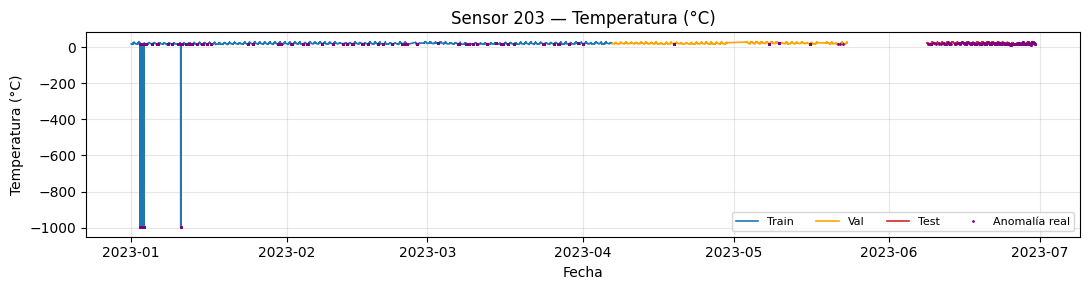

In [14]:
cfg    = DataConfig()
device = torch.device(cfg.device)
print(f'Dispositivo: {device}')

loader  = TimeSeriesLoader(cfg)
df_raw  = loader.load()

print(f'Rango temporal: {df_raw.index.min()} → {df_raw.index.max()}')
print(f'Total muestras: {len(df_raw):,}')
print(f'Distribución Split:\n{df_raw["Split"].value_counts()}')

data_train = df_raw[df_raw['Split'] == 'E'].copy()
data_val   = df_raw[df_raw['Split'] == 'V'].copy()
data_test  = df_raw[df_raw['Split'] == 'T'].copy()

print(f'\nTrain: {len(data_train):,} | Val: {len(data_val):,} | Test: {len(data_test):,}')

# ── Gráfica 1 ─────────────────────────────────────────────────────────────────
VisualizationService.plot_splits(data_train, data_val, data_test)

## Cell 14 — Normalización Z-score

In [15]:
# ── Paso 1: suavizado Butterworth (zero-phase) ANTES de Z-score ───────────────
preprocessor = FiltFiltPreprocessor(cutoff_hz=0.05, order=2, sentinel=cfg.sentinel)

# train: aplicar sobre t_mask (que contiene -2000 donde hay anomalías etiquetadas)
data_train['t_filtered'] = preprocessor.apply(data_train['t_mask'])
data_val['t_filtered']   = preprocessor.apply(data_val['t'])
data_test['t_filtered']  = preprocessor.apply(data_test['t'])

std_cruda    = data_train.loc[data_train['t_mask'] != cfg.sentinel, 't'].std()
std_filtrada = data_train.loc[data_train['t_filtered'] != cfg.sentinel, 't_filtered'].std()
print(f'Std señal cruda    (train, sin sentinel): {std_cruda:.4f}°C')
print(f'Std señal filtrada (train, sin sentinel): {std_filtrada:.4f}°C')

# ── Paso 2: Z-score sobre señal filtrada ──────────────────────────────────────
normalizer = ZScoreNormalizer(sentinel=cfg.sentinel)
normalizer.fit(data_train['t_filtered'], data_train['flag'])

print(f'\nMedia normalizer: {normalizer.mean_:.2f}°C')
print(f'Std   normalizer: {normalizer.std_:.2f}°C')

# t_filtered ya preserva -2000 en posiciones sentinel (FiltFiltPreprocessor.apply lo garantiza)
train_norm = normalizer.transform(data_train['t_filtered'], data_train['t_filtered'])
val_norm   = normalizer.transform(data_val['t_filtered'],   data_val['t_filtered'])
test_norm  = normalizer.transform(data_test['t_filtered'],  data_test['t_filtered'])

print(f'\nEjemplo train_norm (primeros 5): {train_norm.values[:5]}')

Std señal cruda    (train, sin sentinel): 3.1358°C
Std señal filtrada (train, sin sentinel): 3.1320°C

Media normalizer: 21.24°C
Std   normalizer: 3.13°C

Ejemplo train_norm (primeros 5): [-0.6184573  -0.6219005  -0.62545204 -0.6291023  -0.6328372 ]


## Cell 15 — Datasets y DataLoaders

In [16]:
# Entrenamiento: filtrar ventanas con sentinel (filter_masked=True)
train_dataset = MaskedWindowDataset(
    train_norm.values,
    cfg.window_size,
    cfg.stride,
    sentinel=cfg.sentinel,
    filter_masked=True,
)
print(f'Ventanas entrenamiento (filtradas): {len(train_dataset):,}')

train_loader = DataLoaderFactory.create(train_dataset, cfg.batch_size, shuffle=True)  # v2: shuffle=True

# Val: sin filtrado
val_dataset = MaskedWindowDataset(
    val_norm.values, cfg.window_size, cfg.stride,
    sentinel=cfg.sentinel, filter_masked=False,
)
val_loader = DataLoaderFactory.create(val_dataset, cfg.batch_size)
print(f'Ventanas validación:               {len(val_dataset):,}')

# Arrays sin filtrar para inferencia (reconstrucción de serie completa)
train_arr_full = build_unfiltered_windows(train_norm.values, cfg.window_size, cfg.stride)
val_arr        = build_unfiltered_windows(val_norm.values,   cfg.window_size, cfg.stride)
test_arr       = build_unfiltered_windows(test_norm.values,  cfg.window_size, cfg.stride)

print(f'Ventanas test (inferencia):        {len(test_arr):,}')

Ventanas entrenamiento (filtradas): 12,796
Ventanas validación:               5,739
Ventanas test (inferencia):        3,063


## Cell 16 — Instanciar modelo + Transfer Learning por submatriz

In [17]:
# Modelo nuevo (canal único)
model = UsadModelLinear(w_size=cfg.w_size, z_size=cfg.z_size).to(device)
print('Arquitectura del modelo nuevo:')
print(model)

# Cargar pesos preentrenados y transferir submatriz
transfer_svc = WeightTransferService(cfg)
checkpoint   = transfer_svc.load_checkpoint(cfg.model_path)
print(f'\nCheckpoint keys: {list(checkpoint.keys())}')

model = transfer_svc.transfer(model, checkpoint)
print(f'\nTransfer learning completado.')
print(f'  Encoder linear1.weight orig:  {checkpoint["encoder"]["linear1.weight"].shape}')
print(f'  Encoder linear1.weight nuevo: {model.encoder.linear1.weight.shape}')

Arquitectura del modelo nuevo:
UsadModelLinear(
  (encoder): Encoder(
    (linear1): Linear(in_features=30, out_features=15, bias=True)
    (linear2): Linear(in_features=15, out_features=7, bias=True)
    (linear3): Linear(in_features=7, out_features=15, bias=True)
    (relu): ReLU(inplace=True)
  )
  (decoder1): LinearDecoder(
    (linear1): Linear(in_features=15, out_features=7, bias=True)
    (linear2): Linear(in_features=7, out_features=15, bias=True)
    (linear3): Linear(in_features=15, out_features=30, bias=True)
    (relu): ReLU(inplace=True)
  )
  (decoder2): LinearDecoder(
    (linear1): Linear(in_features=15, out_features=7, bias=True)
    (linear2): Linear(in_features=7, out_features=15, bias=True)
    (linear3): Linear(in_features=15, out_features=30, bias=True)
    (relu): ReLU(inplace=True)
  )
)

Checkpoint keys: ['encoder', 'decoder1', 'decoder2']

Transfer learning completado.
  Encoder linear1.weight orig:  torch.Size([306, 612])
  Encoder linear1.weight nuevo: torch

## Cell 16b — Diagnóstico Transfer Learning: arquitecturas y verificación de pesos

In [18]:
# === Diagnóstico Transfer Learning ===
print('=== Comparación de arquitecturas ===')
print(f'Modelo origen (SWaT): w_size={cfg.w_size_orig}  (612D) → z_size={cfg.z_size_orig} (120D)')
print(f'Modelo destino (203): w_size={cfg.w_size:3d}   (30D)  → z_size={cfg.z_size:3d}  (15D)')
print(f'Ratio: {cfg.w_size_orig/cfg.w_size:.1f}x en w_size | {cfg.z_size_orig/cfg.z_size:.1f}x en z_size')

# ── Estadísticas de pesos por capa del encoder ────────────────────────────────
print('\n=== Estadísticas de pesos (encoder) ===')
for name, param in model.encoder.named_parameters():
    if 'weight' in name:
        w_orig = checkpoint['encoder'][name]
        w_new  = param.detach()
        print(f'{name}:')
        print(f'  orig {list(w_orig.shape)}: mean={w_orig.mean():.4f}  std={w_orig.std():.4f}  norm={w_orig.norm():.2f}')
        print(f'  new  {list(w_new.shape)}: mean={w_new.mean():.4f}  std={w_new.std():.4f}  norm={w_new.norm():.2f}')

# ── Verificar que los pesos nuevos son submatriz exacta del checkpoint ────────
print('\n=== Verificación coherencia submatriz ===')
h1 = cfg.w_size // 2
h2 = cfg.w_size // 4

checks = [
    ('linear1.weight', checkpoint['encoder']['linear1.weight'][:h1, :cfg.w_size]),
    ('linear3.weight', checkpoint['encoder']['linear3.weight'][:cfg.z_size, :h2]),
]
all_ok = True
for name, expected in checks:
    actual = dict(model.encoder.named_parameters())[name].detach()
    match  = torch.allclose(actual, expected)
    status = 'OK' if match else 'ADVERTENCIA: no coincide'
    print(f'encoder.{name}: submatriz exacta → {status}')
    all_ok = all_ok and match

if all_ok:
    print('\nTransfer Learning verificado correctamente.')
else:
    print('\nADVERTENCIA: revisar WeightTransferService — alguna capa no coincide.')

=== Comparación de arquitecturas ===
Modelo origen (SWaT): w_size=612  (612D) → z_size=120 (120D)
Modelo destino (203): w_size= 30   (30D)  → z_size= 15  (15D)
Ratio: 20.4x en w_size | 8.0x en z_size

=== Estadísticas de pesos (encoder) ===
linear1.weight:
  orig [306, 612]: mean=-0.0057  std=0.0362  norm=15.87
  new  [15, 30]: mean=-0.0028  std=0.0319  norm=0.68
linear2.weight:
  orig [153, 306]: mean=-0.0030  std=0.0465  norm=10.07
  new  [7, 15]: mean=-0.0073  std=0.0457  norm=0.47
linear3.weight:
  orig [120, 153]: mean=-0.0067  std=0.0728  norm=9.91
  new  [15, 7]: mean=-0.0025  std=0.0587  norm=0.60

=== Verificación coherencia submatriz ===
encoder.linear1.weight: submatriz exacta → OK
encoder.linear3.weight: submatriz exacta → OK

Transfer Learning verificado correctamente.


## Cell 17 — Fase 1: Entrenamiento (encoder congelado, 10 épocas)

In [19]:
strategy = FineTuningStrategy()

strategy.freeze_encoder(model)
print(f'Parámetros entrenables Fase 1: {strategy.count_trainable(model):,}')
print(f'Fase 1: encoder congelado — calentamiento extendido ({cfg.epochs_phase1} épocas) [P1]')

trainer_p1 = UsadFineTuner(model, cfg, device)
history_p1 = trainer_p1.fit(train_loader, val_loader, epochs=cfg.epochs_phase1, early_stopping=False)

print('\nFase 1 completada.')

Parámetros entrenables Fase 1: 1,424
Fase 1: encoder congelado — calentamiento extendido (50 épocas) [P1]
Época [ 10/50]  val_loss1: 1.1806  val_loss2: -0.9450  lr: 1.00e-03
Época [ 20/50]  val_loss1: 1.1765  val_loss2: -1.0625  lr: 5.00e-04
Época [ 30/50]  val_loss1: 1.1662  val_loss2: -1.1020  lr: 5.00e-04
Época [ 40/50]  val_loss1: 1.1693  val_loss2: -1.1272  lr: 5.00e-04
Época [ 50/50]  val_loss1: 1.1699  val_loss2: -1.1371  lr: 2.50e-04

Fase 1 completada.


## Cell 18 — Fase 2: Fine-tuning completo (10 épocas máximo) + Gráfica 2: Curva de entrenamiento

Parámetros entrenables Fase 2: 2,121
Fase 2: fine-tuning completo — hasta 300 épocas, early stopping patience=20 [P1]
Época [ 10/300]  val_loss1: 1.6406  val_loss2: -1.4577  lr: 1.00e-03
Época [ 20/300]  val_loss1: 1.2397  val_loss2: -1.1742  lr: 5.00e-04
Early stopping en época 21 (sin mejora por 20 épocas)


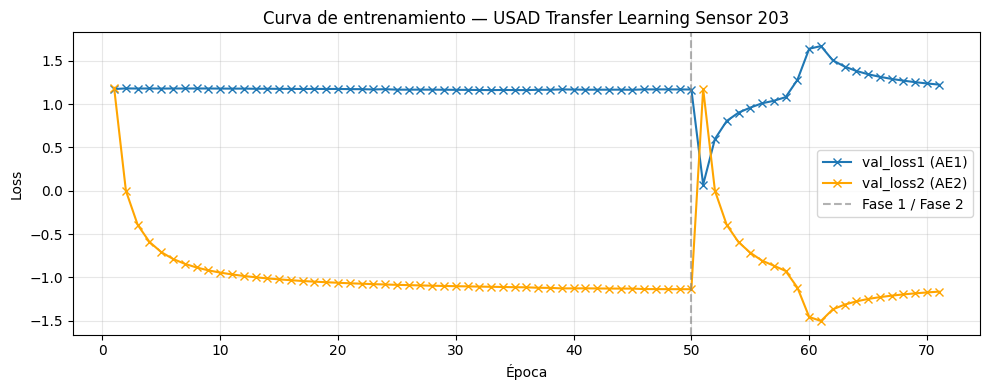

In [20]:
strategy.unfreeze_all(model)
print(f'Parámetros entrenables Fase 2: {strategy.count_trainable(model):,}')
print(f'Fase 2: fine-tuning completo — hasta {cfg.epochs_phase2} épocas, early stopping patience={cfg.patience} [P1]')

trainer_p2 = UsadFineTuner(model, cfg, device)
history_p2 = trainer_p2.fit(train_loader, val_loader, epochs=cfg.epochs_phase2, early_stopping=True)

history = history_p1 + [
    {**h, 'epoch': h['epoch'] + cfg.epochs_phase1} for h in history_p2
]

# ── Gráfica 2 ─────────────────────────────────────────────────────────────────
VisualizationService.plot_training_history(history, phase1_epochs=cfg.epochs_phase1)

## Cell 19 — Inferencia (reconstrucción de series train / val / test)

In [21]:
# P3: reemplazar sentinel en train_norm antes de construir ventanas de inferencia.
# Ventanas con sentinel normalizado (~-648 en Z-score) generaban error de ~51 893.
# Se sustituye por 0 (= media en espacio Z-score) solo para inferencia.
train_norm_infer = train_norm.copy()
train_norm_infer[train_norm_infer == cfg.sentinel] = 0.0

train_arr_full = build_unfiltered_windows(train_norm_infer.values, cfg.window_size, cfg.stride)
val_arr        = build_unfiltered_windows(val_norm.values,         cfg.window_size, cfg.stride)
test_arr       = build_unfiltered_windows(test_norm.values,        cfg.window_size, cfg.stride)

infer_svc = InferenceService(model, normalizer, cfg, device)
print('Reconstruyendo series...')

df_train_concat = infer_svc.compute_errors(train_arr_full, data_train)
df_val_concat   = infer_svc.compute_errors_dual(val_arr,   data_val)
df_test_concat  = infer_svc.compute_errors_dual(test_arr,  data_test)

# P4: normalizar errores antes de combinar.
# En v3, error_d2 era ~16x mayor que error_d1 (0.40 vs 6.39), haciendo que AE2
# dominara el score con α=β=0.5. Se divide cada componente por su media en muestras
# normales de val, dejando que ambos decoders contribuyan equitativamente.
norm_d1 = df_val_concat.loc[df_val_concat['flag'] == 0, 'error_d1'].mean()
norm_d2 = df_val_concat.loc[df_val_concat['flag'] == 0, 'error_d2'].mean()
print(f'Factores de normalización (val normal):  norm_d1={norm_d1:.4f}  norm_d2={norm_d2:.4f}  ratio={norm_d2/norm_d1:.1f}x')

for df in [df_val_concat, df_test_concat]:
    df['error'] = cfg.alpha * (df['error_d1'] / norm_d1) + cfg.beta * (df['error_d2'] / norm_d2)

# Enmascarar filas sentinel en train (P3 ya eliminó valores extremos en ventanas)
n_train        = len(df_train_concat)
sentinel_mask  = data_train.iloc[:n_train]['t_mask'] == cfg.sentinel
df_train_concat.loc[df_train_concat.index[sentinel_mask], 'error'] = np.nan

print(f'Train → {len(df_train_concat):,} pasos | error medio (sin sentinel): {df_train_concat["error"].mean():.4f}')
print(f'Val   → {len(df_val_concat):,} pasos  | error_d1: {df_val_concat["error_d1"].mean():.4f} | error_d2: {df_val_concat["error_d2"].mean():.4f} | combined (norm): {df_val_concat["error"].mean():.4f}')
print(f'Test  → {len(df_test_concat):,} pasos | error_d1: {df_test_concat["error_d1"].mean():.4f} | error_d2: {df_test_concat["error_d2"].mean():.4f} | combined (norm): {df_test_concat["error"].mean():.4f}')


Reconstruyendo series...
Factores de normalización (val normal):  norm_d1=0.0428  norm_d2=12.6768  ratio=295.9x
Train → 133,960 pasos | error medio (sin sentinel): 0.0555
Val   → 57,410 pasos  | error_d1: 0.0428 | error_d2: 12.6415 | combined (norm): 0.9981
Test  → 30,650 pasos | error_d1: 0.0682 | error_d2: 17.2947 | combined (norm): 1.4782


## Cell 20 — Gráfica 3: Precision-Recall Curve + umbral óptimo

In [ ]:
# Opción C: tres candidatos de umbral sobre val
eval_svc   = EvaluationService()
thresholds = eval_svc.find_thresholds(df_val_concat)

print('=== Candidatos de umbral (val) ===')
best_name, best_f1, best_thr = 'youden', -1.0, thresholds['youden']
for name, thr in thresholds.items():
    df_tmp    = eval_svc.apply_threshold(df_val_concat, thr)
    m         = eval_svc.compute_metrics(df_tmp)
    thr_preds = int(df_tmp['flag_pred'].sum())
    print(f"  {name:10s}: thr={thr:.6f}  P={m['precision']:.4f}  R={m['recall']:.4f}  "
          f"F1={m['f1']:.4f}  detecciones={thr_preds}")
    if m['f1'] > best_f1:
        best_f1   = m['f1']
        best_name = name
        best_thr  = thr

# Si todos los F1=0 (caso extremo), usar recall50 para tener señal
if best_f1 == 0.0:
    best_name = 'recall50'
    best_thr  = thresholds['recall50']
    print(f"\n[Nota] Todos F1=0 en val — usando recall50 como fallback.")

umbral = best_thr
print(f"\n>> Umbral seleccionado: {best_name} = {umbral:.6f} (F1 val = {best_f1:.4f})")

# Curva ROC para referencia visual
VisualizationService.plot_roc_threshold(df_val_concat)


## Cell 21 — Gráfica 4: Error de reconstrucción

In [23]:
# Val sin predicciones (exploración)
VisualizationService.plot_error_reconstruction(
    df_val_concat, umbral, label='Validación', show_pred=False
)

# Test con predicciones
VisualizationService.plot_error_reconstruction(
    df_test_concat, umbral, label='Test', show_pred=True
)

## Cell 22 — Aplicar umbral + Gráfica 5: Reconstrucción de la serie

In [ ]:
df_test_concat = eval_svc.apply_threshold(df_test_concat, umbral)
df_val_concat  = eval_svc.apply_threshold(df_val_concat,  umbral)

# Train (sin predicciones)
VisualizationService.plot_series_reconstruction(df_train_concat, show_pred=False)

# Val (sin predicciones)
VisualizationService.plot_series_reconstruction(df_val_concat, show_pred=False)

# Test (con predicciones)
VisualizationService.plot_series_reconstruction(df_test_concat, show_pred=True)


## Cell 23 — Gráfica 6: Métricas de clasificación

In [ ]:
print('=== Métricas (timestep) — Conjunto de Validación ===')
metrics_val = eval_svc.compute_metrics(df_val_concat)
VisualizationService.print_metrics(metrics_val)

print('\n=== Métricas (timestep) — Conjunto de Test ===')
metrics_test = eval_svc.compute_metrics(df_test_concat)
VisualizationService.print_metrics(metrics_test)

# Opción C: métricas por ventana (reduce desbalance de 0.3% → ~9.6% en val)
print('\n=== Métricas (ventana) — Conjunto de Validación ===')
wm_val = eval_svc.compute_window_metrics(df_val_concat, umbral,
                                          window_size=cfg.window_size, stride=cfg.stride)
print(f"  Ventanas: {wm_val['n_windows']}  |  Tasa anomalía: {wm_val['anomaly_rate']*100:.1f}%")
print(f"  P={wm_val['precision']:.4f}  R={wm_val['recall']:.4f}  F1={wm_val['f1']:.4f}  "
      f"BalAcc={wm_val['balanced_accuracy']:.4f}")
cm_w = wm_val['confusion_matrix']
print(pd.DataFrame(cm_w, index=['Pred Normal','Pred Anomalía'],
                   columns=['Real Normal','Real Anomalía']))

print('\n=== Métricas (ventana) — Conjunto de Test ===')
wm_test = eval_svc.compute_window_metrics(df_test_concat, umbral,
                                           window_size=cfg.window_size, stride=cfg.stride)
print(f"  Ventanas: {wm_test['n_windows']}  |  Tasa anomalía: {wm_test['anomaly_rate']*100:.1f}%")
print(f"  P={wm_test['precision']:.4f}  R={wm_test['recall']:.4f}  F1={wm_test['f1']:.4f}  "
      f"BalAcc={wm_test['balanced_accuracy']:.4f}")
cm_wt = wm_test['confusion_matrix']
print(pd.DataFrame(cm_wt, index=['Pred Normal','Pred Anomalía'],
                   columns=['Real Normal','Real Anomalía']))
